###  Architecture Summary (CNN + ANN) used in this Emotion detection:
### VGG (Visual Geometry Group) is a famous CNN architecture developed by researchers at Oxford University.

---

## **CNN Part (Feature Extractor)**

- **Convolution layers**
- **Batch Normalization**
- **ReLU activation**
- **MaxPooling**
- **Dropout**

These layers extract spatial and visual features from the input image.

---

 **Flatten**

Converts the 3D feature maps into a 1D vector so it can be fed into a traditional neural network.

---

## **ANN Part (Classifier)**

- **Dense(512)**
- **Dropout**
- **Dense(num_classes, softmax)**

These layers act as the fully connected classifier and produce the final class probabilities.

---

###  This is the standard structure of many CNN-based classifiers such as **VGG**, **ResNet (top layers)**, **MobileNet head**, etc.


In [164]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab.patches import cv2_imshow
import zipfile
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* Dropout --> Randomly turns off some neurons during training so the model does not depend too much on specific features.
* Conv2D --> Extracts features from images. Applies filters to learn edges, textures, shapes, and high-level features.
* Maxpooling -->  downsample the image. Reduces spatial size, removes noise, and keeps the most important activations.
* flattening --> Converts 2D features into a 1D vector. Prepares the data to feed into fully connected (Dense) layers.
* Batch normalization ---> → Stabilizes and speeds up training. Normalizes activations within a batch so: gradients are stable,training is faster,reduces internal covariate shift can reduce overfitting


- **Dropout** → Prevents overfitting by randomly turning off neurons.
- **Conv2D** → Extracts features from images (edges, textures, shapes).
- **MaxPooling** → Downsamples feature maps and reduces spatial dimensions.
- **Flattening** → Converts 2D feature maps into a 1D vector.
- **Batch Normalization** → Normalizes activations, stabilizes training, and reduces overfitting.


Performs ***Data Augmentation*** (most important)

* It creates new training images by applying random transformations like:
* rotation
* zoom
* width/height shift
* shear
* horizontal flip
* brightness change
* rescale

This helps the model generalize better and reduces overfitting.
**ImageDataGenerator = A tool that performs real-time data augmentation and loads images in batches to improve training and prevent overfitting.**

In [165]:
path = '/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/fer_images.zip'

In [166]:
zip_object = zipfile.ZipFile(file=path, mode = 'r')
zip_object.extractall('./')
zip_object.close()


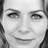

In [167]:
image =  tf.keras.preprocessing.image.load_img('/content/fer2013/train/Happy/54.jpg')
image

In [168]:
training_generator = ImageDataGenerator(rescale= 1.0/255,
                   rotation_range = 7,
                   horizontal_flip = True,
                   vertical_flip = True,
                   zoom_range = 0.2)

In [169]:
training_dataset = training_generator.flow_from_directory('/content/fer2013/train/',
                                       target_size = (48,48),
                                       batch_size = 16,
                                       class_mode = 'categorical',
                                       shuffle  = True
                                       )

Found 28709 images belonging to 7 classes.


In [170]:
training_dataset.classes


array([0, 0, 0, ..., 6, 6, 6], dtype=int32)

In [171]:
np.unique(training_dataset.classes, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6], dtype=int32),
 array([3995,  436, 4097, 7215, 4965, 4830, 3171]))

<Axes: ylabel='count'>

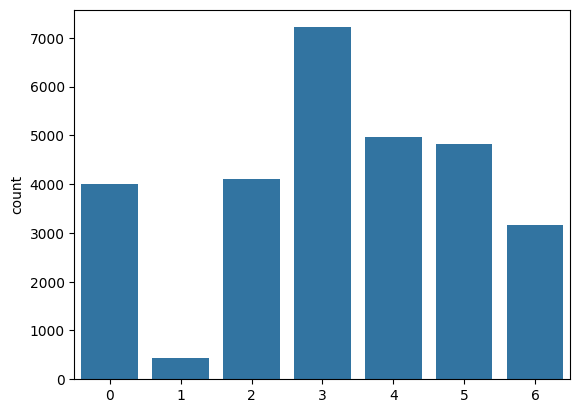

In [172]:
sns.countplot(x = training_dataset.classes)

In [173]:
training_dataset.class_indices

{'Angry': 0,
 'Disgust': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

In [174]:
test_generator = ImageDataGenerator(rescale= 1.0/255)
test_dataset = test_generator.flow_from_directory('/content/fer2013/validation/',
                                       target_size = (48,48),
                                       batch_size = 1,
                                       class_mode = 'categorical',
                                       shuffle  = False
                                       )

Found 3589 images belonging to 7 classes.


https://github.com/rajeevratan84/DeepLearningCV/blob/master/18.2%20Building%20an%20Emotion%20Detector%20with%20LittleVGG.ipynb https://www.pico.net/kb/what-is-the-difference-between-same-and-valid-padding-in-tf-nn-max-pool-of-tensorflow/ https://keras.io/api/layers/normalization_layers/batch_normalization/ https://jmlr.org/papers/volume15/srivastava14a.old/srivastava14a.pdf

### Model Construction

### What is correct in your code?

#### ✔ 1. Conv → BN → Conv → BN → MaxPool → Dropout  
This is a standard pattern used in **VGG-like CNN architectures**.  
It works very well for image classification tasks.

---

#### ✔ 2. Increasing filters in each block  
You correctly increased the number of filters (detectors):

- **Block 1 → 32**
- **Block 2 → 64**
- **Block 3 → 128**
- **Block 4 → 256**

This is the commonly used practice to learn richer features as depth increases.

---

#### ✔ 3. `padding='same'`  
This keeps the spatial height and width the same after each convolution,  
which helps preserve important spatial information before pooling.

---

#### ✔ 4. BatchNormalization used correctly  
Placing **BatchNormalization after each Conv layer** stabilizes training  
and allows faster convergence.

---

#### ✔ 5. Dropout after pooling  
Dropout applied after MaxPooling helps reduce overfitting  
by randomly disabling neurons during training.


| Layer | # Filters | Filter Shape | Output Feature Maps |
| ----- | --------- | ------------ | ------------------- |
| Conv1 | 32        | 3×3×3        | 32                  |
| Conv2 | 64        | 3×3×32       | 64                  |
| Conv3 | 128       | 3×3×64       | 128                 |


In [175]:
num_detectors = 32
num_classes = 7
width, height = 48,48
epochs = 10
# first convolution block
network = Sequential()
network.add(Conv2D(num_detectors, (3,3), activation='relu',padding='same', input_shape = (width,height,3)))
network.add(BatchNormalization()) # normalize the output of the previous layer makes mean=0, std = 1
network.add(Conv2D(num_detectors, (3,3), activation='relu',padding='same'))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2,2))) #Max pooling is a downsampling operation used in Convolutional Neural Networks (CNNs) to reduce the size of feature maps while keeping the most important information.,Max pooling takes a small window (like 2×2 or 3×3) and slides it over the feature map. For each window, it keeps only the maximum value.
network.add(Dropout(0.2)) # Drop 20% of the neuron, reduces over fitting.

# second convolution block
network.add(Conv2D(2*num_detectors, (3,3), activation='relu',padding='same'))
network.add(BatchNormalization())
network.add(Conv2D(2*num_detectors, (3,3), activation='relu',padding='same'))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2,2))) #Max pooling is a downsampling operation used in Convolutional Neural Networks (CNNs) to reduce the size of feature maps while keeping the most important information.,Max pooling takes a small window (like 2×2 or 3×3) and slides it over the feature map. For each window, it keeps only the maximum value.
network.add(Dropout(0.2)) # Drop 20% of the neuron, reduces over fitting.

# Third convolution block
network.add(Conv2D(2*2*num_detectors, (3,3), activation='relu',padding='same'))
network.add(BatchNormalization())
network.add(Conv2D(2*2*num_detectors, (3,3), activation='relu',padding='same'))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2,2))) #Max pooling is a downsampling operation used in Convolutional Neural Networks (CNNs) to reduce the size of feature maps while keeping the most important information.,Max pooling takes a small window (like 2×2 or 3×3) and slides it over the feature map. For each window, it keeps only the maximum value.
network.add(Dropout(0.2)) # Drop 20% of the neuron, reduces over fitting.



# Fourth convolution block
network.add(Conv2D(2*2*2*num_detectors, (3,3), activation='relu',padding='same'))
network.add(BatchNormalization())
network.add(Conv2D(2*2*2*num_detectors, (3,3), activation='relu',padding='same'))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2,2))) #Max pooling is a downsampling operation used in Convolutional Neural Networks (CNNs) to reduce the size of feature maps while keeping the most important information.,Max pooling takes a small window (like 2×2 or 3×3) and slides it over the feature map. For each window, it keeps only the maximum value.
network.add(Dropout(0.2)) # Drop 20% of the neuron, reduces over fitting.

network.add(Flatten()) # After Flatten(), your model becomes a traditional Artificial Neural Network (ANN) (also called a Fully Connected or Dense Network).


network.add(Dense(2*num_detectors, activation= 'relu'))
network.add(BatchNormalization())
network.add(Dropout(0.2))

network.add(Dense(2*num_detectors, activation= 'relu'))
network.add(BatchNormalization())
network.add(Dropout(0.2))

network.add(Dense(num_classes, activation= 'softmax'))
print(network.summary())



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,328,743 (5.07 MB)

 Trainable params: 1,326,567 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

None


# Compile and Train:
*Using Adam.

In [176]:
network.compile(optimizer='Adam', loss = 'categorical_crossentropy', metrics=['accuracy']) # Since it is multi class classification

In [128]:
#train:
network.fit(training_dataset, epochs = epochs)

Epoch 1/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 70s 30ms/step - accuracy: 0.2370 - loss: 1.8969
Epoch 2/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.3211 - loss: 1.6950
Epoch 3/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.3815 - loss: 1.5787
Epoch 4/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 47s 26ms/step - accuracy: 0.4276 - loss: 1.4800
Epoch 5/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.4637 - loss: 1.4000
Epoch 6/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - accuracy: 0.4855 - loss: 1.3588
Epoch 7/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - accuracy: 0.4982 - loss: 1.3150
Epoch 8/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.5134 - loss: 1.2870
Epoch 9/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.5266 - loss: 1.2521
Epoch 10/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.5343 - loss: 1.2298


# save the model

In [129]:
model_json = network.to_json()
with open('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/network_emotions.json','w') as json_file:
  json_file.write(model_json)

In [130]:
#Saving weghts
from keras.models import save_model
network_saved =  save_model(network, '/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/weights_emotions.hdf5')

In [131]:
# Just Another way to save the weights.
network.save_weights('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/demo.weights.h5')

In [132]:
# To read the model:
with open('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/network_emotions.json','r') as json_file:
  json_saved_model = json_file.read()

In [133]:
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential_2", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 48, 48, 3], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer_2", "optional": false}, "registered_name": null}, {"module": "keras.layers", "class_name": "Conv2D", "config": {"name": "conv2d_16", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "filters": 32, "kernel_size": [3, 3], "strides": [1, 1], "padding": "same", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias

In [134]:
loaded_network = tf.keras.models.model_from_json(json_saved_model)
loaded_network.load_weights('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/weights_emotions.hdf5')


In [135]:
loaded_network.compile(loss = 'categorical_crossentropy', optimizer='Adam', metrics= ['accuracy'])
loaded_network.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,328,743 (5.07 MB)

 Trainable params: 1,326,567 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

## Evaluate the neural network using test set:

In [136]:

loaded_network.evaluate(test_dataset)

3589/3589 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.4717 - loss: 1.4825


[1.4825248718261719, 0.4717191457748413]

In [ ]:
predictions = loaded_network.predict(test_dataset)
predictions

3589/3589 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step


array([[0.2658001 , 0.06152141, 0.27082878, ..., 0.11203307, 0.2638678 ,
        0.01953096],
       [0.6599982 , 0.02501622, 0.16504914, ..., 0.00538124, 0.02405639,
        0.00801605],
       [0.8184817 , 0.01954112, 0.08172962, ..., 0.01943741, 0.04469932,
        0.00236054],
       ...,
       [0.02735906, 0.00529001, 0.2678913 , ..., 0.04461677, 0.03284709,
        0.60548186],
       [0.04208465, 0.00159241, 0.0757829 , ..., 0.7195019 , 0.047126  ,
        0.10736265],
       [0.03399973, 0.00176546, 0.08558276, ..., 0.09773158, 0.05519266,
        0.6837576 ]], dtype=float32)

In [ ]:
predictions[0] # these are probabilites (of 7 classes)

array([0.2658001 , 0.06152141, 0.27082878, 0.00641798, 0.11203307,
       0.2638678 , 0.01953096], dtype=float32)

In [ ]:
np.argmax(predictions[0])

np.int64(2)

In [ ]:
test_dataset.class_indices

{'Angry': 0,
 'Disgust': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

In [141]:
# for all test image:
predictions = np.argmax(predictions, axis=1)
predictions

array([0, 0, 0, ..., 6, 6, 6])

In [ ]:
test_dataset.class_indices

{'Angry': 0,
 'Disgust': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
accuracy_score(test_dataset.classes, predictions)

0.47450543326831984

In [ ]:
confusion_matrix(test_dataset.classes, predictions)


array([[242,   0,  21,  50, 102,  70,   6],
       [ 27,   0,   3,   9,   1,  14,   1],
       [ 98,   1,  47,  54, 173, 106,  49],
       [ 21,   0,   4, 747,  58,  37,  12],
       [114,   0,  17, 163, 190,  91,  51],
       [ 72,   0,  17,  58, 207, 235,   5],
       [ 15,   0,  26,  41,  83,   9, 242]])

In [ ]:
image = cv2.imread('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/image_check.jpg')

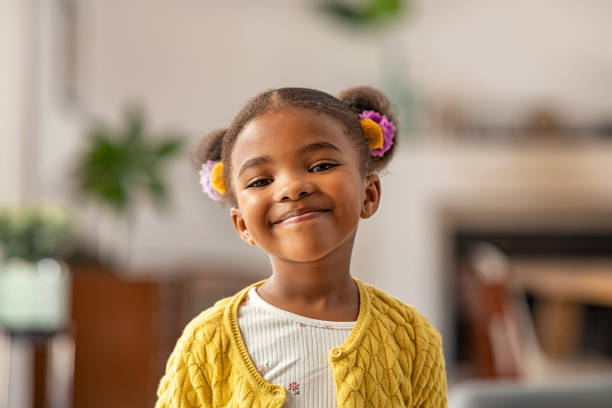

In [147]:
cv2_imshow(image)

In [148]:
image.shape

(408, 612, 3)

In [149]:
roi = cv2.resize(image,(48,48))
roi = roi/255 # normalized

In [150]:
roi = np.expand_dims(roi, axis = 0)

In [151]:
roi.shape

(1, 48, 48, 3)

In [152]:
prob = loaded_network.predict(roi)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step    


In [153]:
np.argmax(prob)

np.int64(3)

In [154]:
test_dataset.class_indices

{'Angry': 0,
 'Disgust': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

## It predicted correctly.

## Classifying Emotions in videos

In [155]:
face_detector = cv2.CascadeClassifier('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/08_Face_detection_using_Haar_cascade/haarcascade_frontalface_default.xml')


In [156]:
testImagePath = '/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/faces_emotions.png'

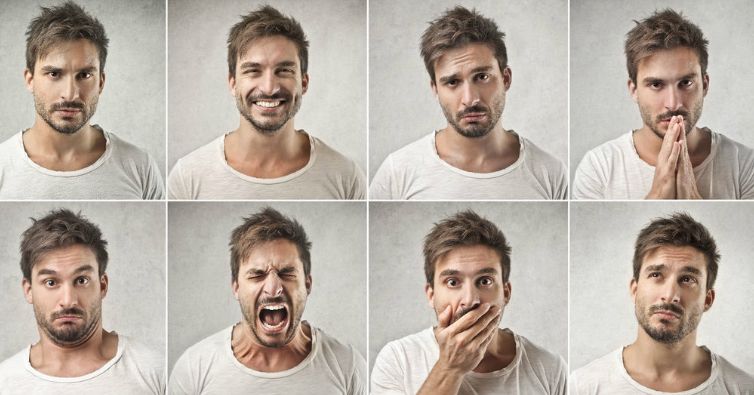

In [157]:
image = cv2.imread(testImagePath)
cv2_imshow(image)

In [158]:
faces = face_detector.detectMultiScale(image)
faces

array([[224,  35,  90,  90],
       [ 23,  41,  92,  92],
       [420,  43,  97,  97],
       [625,  49,  91,  91],
       [420, 242,  97,  97],
       [ 18, 243,  98,  98],
       [229, 242,  85,  85],
       [627, 241,  91,  91]], dtype=int32)

In [159]:
test_dataset.class_indices.keys()
emotions = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


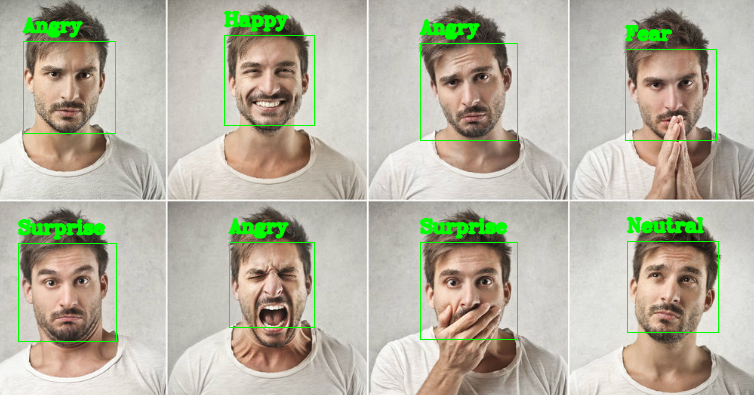

In [160]:
for (x,y,w,h) in faces:
  cv2.rectangle(image, (x,y), (x+w, y+h), (0,255,0), 1)
  roi = image[y:y+h, x:x+w]
  roi = cv2.resize(roi,(48,48))

  roi = roi/255
  roi = np.expand_dims(roi, axis=0)
  #print(roi.shape)
  prediction = loaded_network.predict(roi)
  #print(prediction)
  cv2.putText(image, emotions[np.argmax(prediction)],(x,y-10), cv2.FONT_HERSHEY_COMPLEX, 0.6, (0,255,0), 2,cv2.LINE_AA)



cv2_imshow(image)

In [161]:
cap = cv2.VideoCapture('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/emotion_test01.mp4')
connected, video = cap.read()
print(connected, video.shape)


True (360, 640, 3)


In [162]:
# Output video file name
save_path = '/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/11_Emotion_classification/emotion_test01_result.avi'

# Define video codec
fourcc = cv2.VideoWriter_fourcc(*'mp4V')

# Create VideoWriter object
output_video = cv2.VideoWriter(save_path, fourcc, 24, (video.shape[1], video.shape[0]))

while True:
    connected, frame = cap.read()
    
    if not connected:
        break

    faces = face_detector.detectMultiScale(
        frame,
        scaleFactor=1.2,
        minNeighbors=5,
        minSize=(30,30)
    )

    if len(faces) > 0:
        for (x,y,w,h) in faces:

            frame = cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)

            roi = frame[y:y+h, x:x+w]
            roi = cv2.resize(roi,(48,48))
            roi = roi / 255

            roi = np.expand_dims(roi, axis=0)

            prediction = loaded_network.predict(roi)

            if prediction is not None:
                result = np.argmax(prediction)

                cv2.putText(frame,
                            emotions[result],
                            (x,y-10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.5,
                            (255,255,255),
                            1,
                            cv2.LINE_AA)

    cv2_imshow(frame)
    output_video.write(frame)

print('End')

output_video.release()
cv2.destroyAllWindows()

In [ ]:
while (cv2.waitKey(1) < 0):
  connected, frame = cap.read()
  if not connected:
    break
  faces = face_detector.detectMultiScale(frame, scaleFactor=1.2, minNeighbors=5,
                                         minSize=(30,30))
  if len(faces)>0:
    for (x,y,w,h) in faces:
      frame = cv2.rectangle(frame, (x,y),(x+w,y+h), (0,255,0),2)
      roi = frame[y:y+h,x:x+w]
      roi = cv2.resize(roi,(48,48))
      roi=roi/255
      roi = np.expand_dims(roi,axis=0)
      prediction = loaded_network.predict(roi)

      if prediction is not None:
        result = np.argmax(prediction)
        cv2.putText(frame,emotions[result],(x,y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255),1,cv2.LINE_AA)
    cv2_imshow(frame)
    output_video.write(frame)
print('End')
output_video.release()
cv2.destroyAllWindows()
